<a href="https://colab.research.google.com/github/aiden-dm/CSCI-4170/blob/main/CSCI_4170_Homework_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Projects in AI and ML - Homework 4**
##**Aiden Drover-Mattinen**

# Task 2

I chose to use a Recurrent Neural Network (RNN) to predict Google’s future stock price because stock prices are inherently time-dependent—past trends and patterns influence future values. Additionally, stock prices follow a sequential structure, with daily fluctuations driven by previous price movements. This makes sequence models like RNNs well-suited for capturing these dependencies and learning meaningful patterns in the data.

The dataset I’m using for this task is sourced from Kaggle: [Google Stock Price](https://www.kaggle.com/datasets/henryshan/google-stock-price) dataset

## Part 1

### Data Pre-Processing and Visualization

The first step in preprocessing and visualizing the data is importing it from the dataset. Below, I load the .csv file I downloaded from the provided Kaggle link and display the first few rows.

In [1]:
import pandas as pd

# Read in the data from a csv file
data = pd.read_csv('/content/drive/MyDrive/CSCI4170_Datasets/GOOG.csv')

# Print the first few rows to see what the data looks like
data.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2004-08-19,2.490664,2.591785,2.390042,2.499133,2.499133,897427216
1,2004-08-20,2.515820,2.716817,2.503118,2.697639,2.697639,458857488
2,2004-08-23,2.758411,2.826406,2.716070,2.724787,2.724787,366857939
3,2004-08-24,2.770615,2.779581,2.579581,2.611960,2.611960,306396159
4,2004-08-25,2.614201,2.689918,2.587302,2.640104,2.640104,184645512


The next step is handling any missing values. Below, I’ve written code to check whether the dataset contains any missing entries.

In [2]:
# Checking if there are any missing values
print(data.isnull().sum())

Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64


Fortunately, the dataset is already well-structured, with no missing values. Next, I extract the features to be used in the models. Specifically, I’ve chosen Date (to maintain the sequence of information), along with Open, High, Low, and Close.

In [3]:
# Extract the features that we want to use
features = ['Date', 'Open', 'High', 'Low', 'Close']
data = data[features]
data.head()

,Date,Open,High,Low,Close
0,2004-08-19,2.490664,2.591785,2.390042,2.499133
1,2004-08-20,2.515820,2.716817,2.503118,2.697639
2,2004-08-23,2.758411,2.826406,2.716070,2.724787
3,2004-08-24,2.770615,2.779581,2.579581,2.611960
4,2004-08-25,2.614201,2.689918,2.587302,2.640104


The next step is to visualize the imported dataset. Stock data is typically represented using a time-series plot to observe fluctuations in value over time. Below, I've plotted each feature in different colors, and as expected, they all follow nearly identical trends.

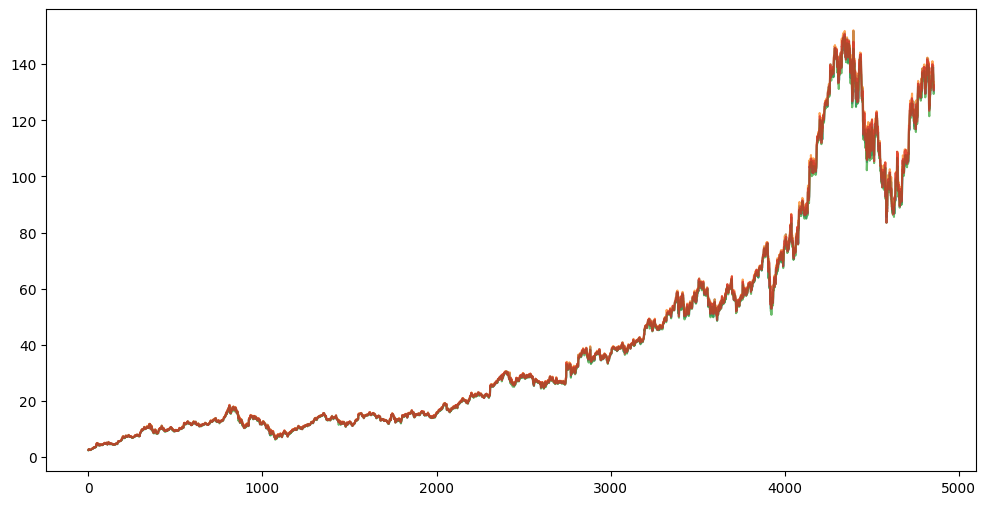

In [4]:
import matplotlib.pyplot as plt

# Creating a time-series plot to visualize data
plt.figure(figsize=(12, 6))
plt.plot(data["Open"], label="Open", alpha=0.7)
plt.plot(data["High"], label="High", alpha=0.7)
plt.plot(data["Low"], label="Low", alpha=0.7)
plt.plot(data["Close"], label="Close", alpha=0.7)

In [5]:
# Installing mpl finance for next visualization
!pip install mplfinance

Another way to visualize stock data is with the use of a candlestick chart, which is able to capture open, high, low, and close prices in a single visualization, which is perfect for the features we've chosen to include in our model. In the below graph, the green body means that the stock closed higher than it opened on a given day, and red means that it closed lower than it opened.

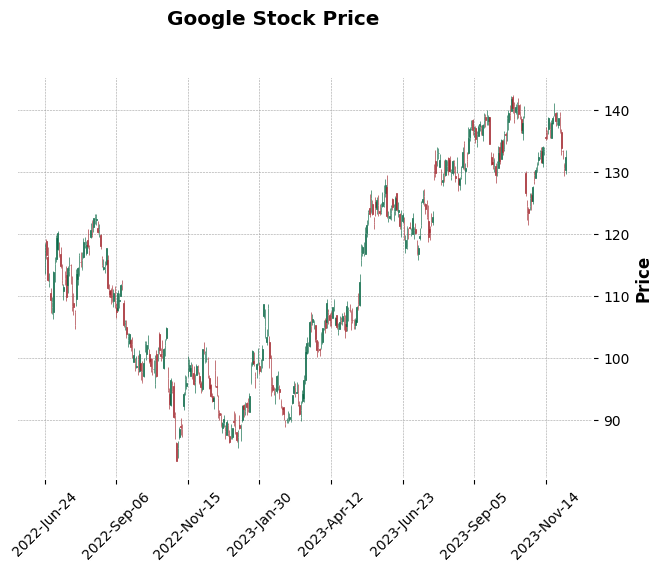

In [6]:
import mplfinance as mpf

# Converting "Date" column to datetime format
data['Date'] = pd.to_datetime(data['Date'])

# Setting "Date" column as the index
data.set_index('Date', inplace=True)

# Filter the last year of data to see details
last_year_data = data.tail(365)

# Creating a candlestick plot (common for representing stocks)
mpf.plot(last_year_data, type='candle', style='charles', volume=False, title='Google Stock Price')


You may notice that I have only chosen to include data since 2022 in the above chart. This is because including the entire dataset made it impossible to see the green and red colors. As a result, the candlestick chart shows us that the stock price has has many periods of closing at a higher or lower price than opening price without much of a consistent trend as the Google stock has generally risen since 2022.

Another visualization strategy is to plot a heatmap showing the correlation between my model features. I have done this below:

           Open      High       Low     Close
Open   1.000000  0.999903  0.999896  0.999774
High   0.999903  1.000000  0.999875  0.999894
Low    0.999896  0.999875  1.000000  0.999904
Close  0.999774  0.999894  0.999904  1.000000


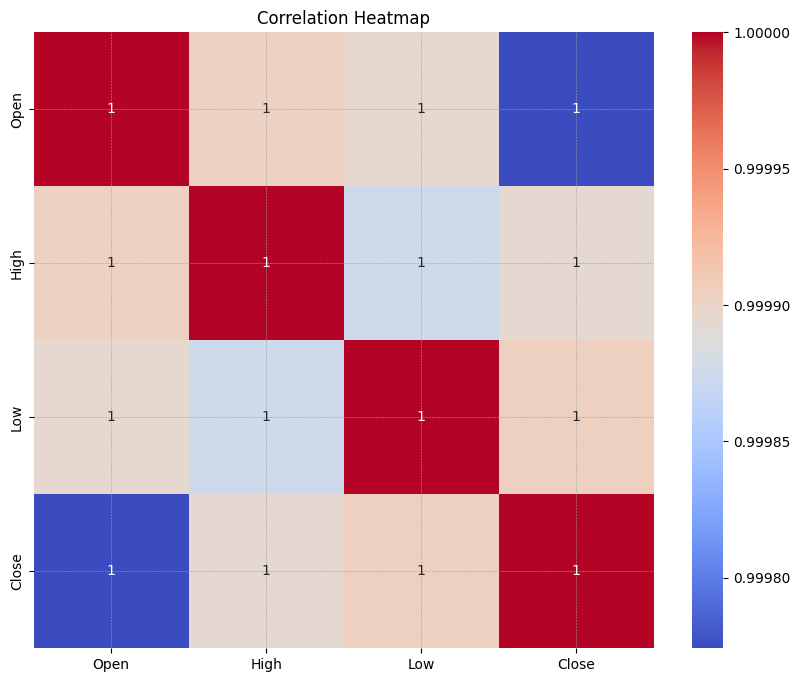

In [7]:
import seaborn as sns

# Compute correlation matrix (only numeric columns)
corr_matrix = data.select_dtypes(include=["number"]).corr()
print(corr_matrix)

# Creating a correlation heatmap (checking for feature relationships)
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

Interestingly, the correlation between every feature is nearly 1. This is expected, as values derived from the same stock price tend to be very similar, resulting in a high correlation, which is clearly reflected in the heatmap. This also aligns with the time-series plot, where all trends appeared nearly identical.

With visualization complete, the next step is preparing the data for the RNN. First, we normalize the data between 0 and 1, as neural networks generally perform better when inputs are scaled to a consistent range, preventing larger values from dominating the learning process.

Source:
* https://medium.com/towards-data-science/why-data-should-be-normalized-before-training-a-neural-network-c626b7f66c7d



In [8]:
from sklearn.preprocessing import MinMaxScaler

# Normalize the data between values 0-1
scaler = MinMaxScaler()
data = scaler.fit_transform(data)    # data becomes NumPy array
print(data)

[[1.35039790e-04 3.86337794e-04 0.00000000e+00 5.54588186e-05]
 [3.03427861e-04 1.22230316e-03 7.66630177e-04 1.39474206e-03]
 [1.92727230e-03 1.95501646e-03 2.21039746e-03 1.57790459e-03]
 ...
 [8.75874456e-01 8.75640149e-01 8.79757220e-01 8.82679683e-01]
 [8.62312904e-01 8.61933805e-01 8.61099278e-01 8.64530737e-01]
 [8.56127802e-01 8.75907542e-01 8.63336618e-01 8.76405091e-01]]


The next step is to transform our Google stock price data into sequences, as RNNs learn from sequential patterns. This involves converting the time-series data into overlapping input-output pairs, where past values are used to predict future values. Below, I define a function to perform this transformation. Specifically, my network will use all four features as input while attempting to predict the Close price.

In [9]:
import numpy as np

# Create sequences of data for the RNN
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i : i+seq_length, :])    # include all 4 features
        y.append(data[i+seq_length, 3])        # only the close price
    return np.array(X), np.array(y)

# Assign the sequence length
seq_length = 60

# Create the sequences for the model
X, y = create_sequences(data, seq_length)

print(f"Shape of X: {X.shape}")
print(f"Shape of y: {y.shape}")

Shape of X: (4798, 60, 4)
Shape of y: (4798,)


As in previous assignments, it is essential to split the data into training, development (dev), and test sets. The training set is used to train the RNN, the dev set helps fine-tune hyperparameters and prevent overfitting, and the test set provides an unbiased evaluation of the model's performance on unseen data. This structured approach ensures that the model generalizes well to new data.

In [10]:
# Saving the sizes of the train, dev, and test sets
train_size = int(0.7 * len(X))                 # 70% of the data
dev_size = int(0.15 * len(X))                  # 15% of the data
test_size = len(X) - train_size - dev_size     # 15% of the data

# Splitting the data into train, dev, and test
X_train, y_train = X[:train_size], y[:train_size]
X_dev, y_dev = X[train_size:train_size+dev_size], y[train_size:train_size+dev_size]
X_test, y_test = X[-test_size:], y[-test_size:]

### Implementing the RNN

Building on my experience with the high-level Keras API from Homework 3, I have designed a simple RNN with 64 units. This strikes a balance between capturing sequential dependencies and maintaining computational efficiency, given the sequence length of 60. The network has a single output node, as its goal is to predict the closing price of Google stock for a given day. I chose to use the tanh activation function because of its frequent usage in recurrent networks.

Source:
* https://stanford.edu/~shervine/teaching/cs-230/cheatsheet-recurrent-neural-networks

In [11]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense

# Creating the simple RNN model
rnn = Sequential()
rnn.add(SimpleRNN(units=64, activation='tanh', return_sequences=False, input_shape=(seq_length, 4)))
rnn.add(Dense(units=1))

# Displaying model summary
rnn.summary()

# Compiling the model
rnn.compile(optimizer='adam', loss='mean_squared_error')

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)               │ (None, 64)                  │           4,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,481 (17.50 KB)

 Trainable params: 4,481 (17.50 KB)

 Non-trainable params: 0 (0.00 B)

With the model set up, it can now be trained. I chose 6 epochs to balance minimizing the cost function while avoiding overfitting.

In [12]:
# Training the model
rnn_history = rnn.fit(X_train, y_train, epochs=6)

Epoch 1/6
105/105 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - loss: 0.0018
Epoch 2/6
105/105 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - loss: 4.1392e-05
Epoch 3/6
105/105 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - loss: 3.2477e-05
Epoch 4/6
105/105 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - loss: 3.1231e-05
Epoch 5/6
105/105 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - loss: 2.9188e-05
Epoch 6/6
105/105 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 2.1760e-05


With the model trained, I can now generate predictions on the dev set to get an idea of how the model is performing.

In [13]:
# Make predictions on the dev data to evaluate performance
rnn_preds = rnn.predict(X_dev)

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


To quantify the performance of the model, I have implemented a function that calculates the Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and Mean Absolute Percentage Error (MAPE). These are commonly used performance metrics for RNNs, and I have briefly defined them below:

* Mean Absolute Error (MAE): Measures the average absolute difference between predicted and actual values. Lower values indicate better accuracy.
* Root Mean Squared Error (RMSE): Similar to MAE but gives more weight to larger errors, making it useful for identifying significant deviations.
* Mean Absolute Percentage Error (MAPE): Expresses error as a percentage of actual values, making it easier to interpret across different scales.

Source:
* https://encord.com/blog/time-series-predictions-with-recurrent-neural-networks/#:~:text=To%20assess%20the%20performance%20of,Absolute%20Percentage%20Error%20(MAPE)



In [14]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, mean_absolute_percentage_error

# Function to calculate performance metrics
def evaluate_performance(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = root_mean_squared_error(y_true, y_pred,)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100

    print(f"Mean Absolute Error (MAE): {mae}")
    print(f"Root Mean Squared Error (RMSE): {rmse}")
    print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")

# Displaying the performance metrics for the model
evaluate_performance(y_dev, rnn_preds)

Mean Absolute Error (MAE): 0.010318203111369571
Root Mean Squared Error (RMSE): 0.014026077695629642
Mean Absolute Percentage Error (MAPE): 2.45%


## Part 2

### Implementing a LSTM

Now we are going to improve upon the simple RNN by implementing a LSTM. An LSTM improves over standard RNNs by addressing the vanishing gradient problem, which limits RNNs' ability to learn long-term dependencies. They achieve this through a memory cell and three gates (forget, input, and output) that selectively retain or discard information. This allows LSTMs to effectively handle long sequences, maintain relevant context, and reduce gradient loss during training. Again, I have used the Keras TensorFlow API below.

Source:
* https://www.geeksforgeeks.org/deep-learning-introduction-to-long-short-term-memory/

In [15]:
from keras.layers import LSTM

# Defining the LSTM model
lstm = Sequential()
lstm.add(LSTM(64, activation='tanh', input_shape=(seq_length, 4)))
lstm.add(Dense(1))
lstm.summary()

# Compiling the model
lstm.compile(optimizer='adam', loss='mse')

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 64)                  │          17,664 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 17,729 (69.25 KB)

 Trainable params: 17,729 (69.25 KB)

 Non-trainable params: 0 (0.00 B)

With the model created, it can now be trained on the training data.

In [16]:
# Training the model
lstm_history = lstm.fit(X_train, y_train, epochs=6)

Epoch 1/6
105/105 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - loss: 0.0018
Epoch 2/6
105/105 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - loss: 2.3147e-05
Epoch 3/6
105/105 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 2.0896e-05
Epoch 4/6
105/105 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - loss: 1.7672e-05
Epoch 5/6
105/105 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - loss: 1.8907e-05
Epoch 6/6
105/105 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - loss: 2.0046e-05


Next, predictions can be created to help evaluate the performance of the model.

In [17]:
# Make predictions on the dev data to evaluate performance
lstm_preds = lstm.predict(X_dev)

23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step


We can now call the previously-defined evaluate_performance() function to get the same performance metrics that were used to evaluate the RNN model.

In [18]:
# Displaying the performance metrics for the model
evaluate_performance(y_dev, lstm_preds)

Mean Absolute Error (MAE): 0.009416552709583338
Root Mean Squared Error (RMSE): 0.012922261140774743
Mean Absolute Percentage Error (MAPE): 2.29%


### Implementing a GRU

Now, we will improve upon the simple RNN by implementing a GRU model. GRUs, like LSTMs, address the vanishing gradient problem to better capture long-term dependencies. However, GRUs simplify the architecture by using only two gates (reset and update) instead of three, making them computationally more efficient while still preserving key information over long sequences. This allows GRUs to achieve similar performance to LSTMs in many tasks while reducing training time and complexity. Again, I have used the Keras TensorFlow API below.

Source:
* https://www.geeksforgeeks.org/gated-recurrent-unit-networks/

In [19]:
from keras.layers import GRU

# Defining the GRU model
gru = Sequential()
gru.add(GRU(units=50, activation='tanh', input_shape=(seq_length, 4)))
gru.add(Dense(1))
gru.summary()

# Compiling the model
gru.compile(optimizer='adam', loss='mse')

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ gru (GRU)                            │ (None, 50)                  │           8,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 8,451 (33.01 KB)

 Trainable params: 8,451 (33.01 KB)

 Non-trainable params: 0 (0.00 B)

With the model created, it can be trained as follows.

In [20]:
# Training the model
gru_history = gru.fit(X_train, y_train, epochs=6)

Epoch 1/6
105/105 ━━━━━━━━━━━━━━━━━━━━ 7s 36ms/step - loss: 0.0068
Epoch 2/6
105/105 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - loss: 1.6476e-05
Epoch 3/6
105/105 ━━━━━━━━━━━━━━━━━━━━ 6s 39ms/step - loss: 1.3342e-05
Epoch 4/6
105/105 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - loss: 1.3978e-05
Epoch 5/6
105/105 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - loss: 1.5074e-05
Epoch 6/6
105/105 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - loss: 1.2393e-05


In [21]:
# Make predictions on the dev data to evaluate performance
gru_preds = gru.predict(X_dev)

23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step


In [22]:
# Displaying the performance metrics for the model
evaluate_performance(y_dev, gru_preds)

Mean Absolute Error (MAE): 0.007487608094980562
Root Mean Squared Error (RMSE): 0.010162321936088778
Mean Absolute Percentage Error (MAPE): 1.80%


### Discussion of RNN, LSTM, and GRU Differences

#### Visualizing Loss Function Values During Training

To compare the progression of the three algorithms, we will extract their loss values across epochs and visualize the results. This will be done using both a graph, to observe trends over time, and a table, to provide precise numerical comparisons.

In [23]:
# Extracting loss information from history variables
rnn_loss = rnn_history.history['loss']
lstm_loss = lstm_history.history['loss']
gru_loss = gru_history.history['loss']

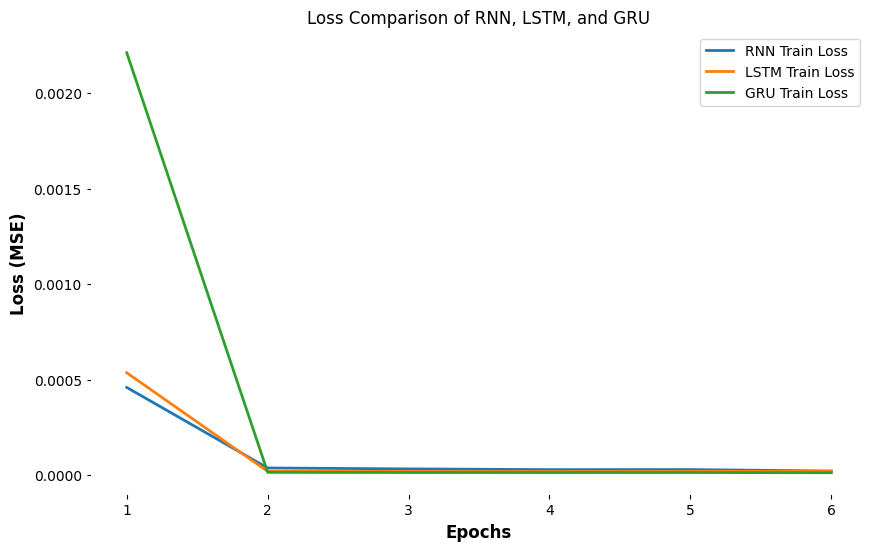

In [24]:
# Plotting the losses across epochs
epochs = list(range(1, len(rnn_loss) + 1))  # Epoch numbers
plt.figure(figsize=(10, 6))
plt.plot(epochs, rnn_loss, label="RNN Train Loss")
plt.plot(epochs, lstm_loss, label="LSTM Train Loss")
plt.plot(epochs, gru_loss, label="GRU Train Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss (MSE)")
plt.title("Loss Comparison of RNN, LSTM, and GRU")
plt.legend()
plt.grid()
plt.show()


In [25]:
# Showing the loss values across epochs in a table
epochs = list(range(1, len(rnn_loss) + 1))
loss_data = {
    "Epoch": epochs,
    "RNN Loss": rnn_loss,
    "LSTM Loss": lstm_loss,
    "GRU Loss": gru_loss
}

df_loss = pd.DataFrame(loss_data)
print(df_loss)

   Epoch  RNN Loss  LSTM Loss  GRU Loss
0      1  0.000459   0.000536  0.002211
1      2  0.000037   0.000020  0.000014
2      3  0.000032   0.000019  0.000014
3      4  0.000029   0.000019  0.000013
4      5  0.000029   0.000019  0.000013
5      6  0.000021   0.000020  0.000012


The loss values across epochs show that all three models (RNN, LSTM, and GRU) improve over time, with decreasing loss values. Despite starting with a significantly higher loss, GRU consistently achieves the lowest loss, indicating better performance in this case. The LSTM and RNN follow very similar paths as their costs converge, both finishing at a value around 0.000020. Overall, GRU appears to be the most effective, likely due to its ability to capture long-term dependencies efficiently with fewer parameters compared to LSTM.

#### Comparison of Performance Metrics on Test Set

It is essential to evaluate all three models on the test data and compare their performance metrics directly. To ensure a fair comparison, I used the same number of epochs, the tanh activation function, the Adam optimization algorithm, and the Mean Squared Error (MSE) loss function across all models.

Adam is my preferred optimization algorithm from class because it combines the benefits of Momentum and RMSProp, adapting the learning rate dynamically for efficient convergence. I chose MSE as the loss function because it is widely used for RNN, LSTM, and GRU models in time-series forecasting.

In [26]:
# Generating predictions for RNN, LSTM and GRU
rnn_test_preds = rnn.predict(X_test)
lstm_test_preds = lstm.predict(X_test)
gru_test_preds = gru.predict(X_test)

# Printing evaluation metrics for the three models
print("RNN Performance Metrics:")
evaluate_performance(y_test, rnn_test_preds)
print("\nLSTM Performance Metrics:")
evaluate_performance(y_test, lstm_test_preds)
print("\nGRU Performance Metrics:")
evaluate_performance(y_test, gru_test_preds)

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
RNN Performance Metrics:
Mean Absolute Error (MAE): 0.07901412508810039
Root Mean Squared Error (RMSE): 0.0901705678457001
Mean Absolute Percentage Error (MAPE): 9.41%

LSTM Performance Metrics:
Mean Absolute Error (MAE): 0.030883782866027165
Root Mean Squared Error (RMSE): 0.03702099619757729
Mean Absolute Percentage Error (MAPE): 3.77%

GRU Performance Metrics:
Mean Absolute Error (MAE): 0.0246547336097744
Root Mean Squared Error (RMSE): 0.029810816739661156
Mean Absolute Percentage Error (MAPE): 3.01%


The results show that the GRU consistently outperforms both the LSTM and the simple RNN in terms of accuracy. It achieves the lowest error across all metrics, making it the most effective model for predicting Google stock prices in this case. The LSTM also performs well but is slightly less accurate than the GRU, while the simple RNN has the highest errors, struggling to capture complex temporal dependencies.

Several factors may explain the GRU's superior performance. With fewer parameters than LSTMs, GRUs train faster and reduce the risk of overfitting, making them effective for smaller datasets. They also handle vanishing gradients well while balancing short- and long-term dependencies, allowing them to learn stock price patterns efficiently. LSTMs, while powerful for longer sequences, may not have had a significant advantage here, and the simple RNN likely struggled due to its lack of memory mechanisms.

## Part 3: Can A Traditional Feed-Forward Network Solve The Problem?



Yes, a traditional feed-forward network (MLP) can be used to solve time series forecasting problems, but is limited relative to RNNs, LSTMs, and GRUs. Since feed-forward networks do not inherently handle sequential dependencies, time series data must first be transformed into structured input features. A common approach to achieve this is the sliding window method.

With the sliding window method, past observations (e.g., the last 10 time steps) are used as input features, and the network predicts the next time step. This method works well for short-term dependencies but struggles with capturing long-term patterns.

Overall, while an MLP can be used for time series forecasting with proper data pre-processing, it lacks the ability to retain temporal relationships efficiently. Recurrent architectures like LSTMs and GRUs are generally better suited for capturing long-term dependencies in sequential data.

Sources:
* https://www.youtube.com/watch?v=SyHVMAjL-I0
* https://machinelearningmastery.com/time-series-forecasting-supervised-learning/


# Task 3

## Part 1: Implementing Word Embeddings

I chose to implement FastText as my word embedding method instead of alternatives like Word2Vec, GloVe, and BERT.

At first, the most obvious reason for choosing FastText would be its ability to handle out-of-vocabulary (OOV) words by representing words as character n-grams rather than full-word units like Word2Vec and GloVe. However, since the Gensim version I used does not support OOV word generation, this was not a deciding factor. Instead, I still found FastText valuable because its n-gram approach provides richer subword information, allowing it to capture word morphology better than Word2Vec and GloVe.

Compared to BERT, FastText offers a much more computationally efficient solution while still capturing meaningful word relationships. While BERT's contextual embeddings are more powerful, they require significantly more resources. Given the computational limits of Google Colab, FastText strikes the right balance between efficiency and performance, making it the best choice for my implementation.

I start my implementation of FastText below by downloading the FastText vectors:

In [27]:
import gensim.downloader as api

# Download the FastText vectors (from Wikipedia)
fasttext_model = api.load('fasttext-wiki-news-subwords-300')

Next, I implement a function to get the embedding for a word using FastText. Since my Gensim implementation is not able to automatically handle OOV words, I have implemented some simple methods to handle them myself. If my code encounters a OOV word, it first attempts to find close matches using the difflib library. Specifically, it applies the Ratcliff/Obershelp algorithm with the get_close_matches() function, which finds the longest common subsequence (LCS) between two strings and uses it to calculate a similarity ratio. The algorithm recursively identifies matching substrings, giving higher similarity scores to words with more overlapping characters in the same order. This is to handle the case where the word is a slight typo or very similar in structure to another word. If there are no close matches, I simply opt to return a zero vector.

The methods I used to handle OOV words—finding close matches with difflib and returning a zero vector when no match is found—each have drawbacks. Using difflib relies on surface-level similarity, which may lead to incorrect substitutions if a similar-looking word has a different meaning. Returning a zero vector treats all unknown words as identical, losing any semantic contribution they might have had. While these approaches ensure the model can process input without errors, they introduce potential inaccuracies and may weaken the overall representation quality, especially if OOV words appear frequently.

Source:
* https://docs.python.org/3/library/difflib.html

In [28]:
import difflib

# Finds the closest word using Ratcliff/Obershelp algorithm
def closest_word(word, model):
  # Get all words in vocabulary
  vocab = list(model.key_to_index.keys())
  best_match = difflib.get_close_matches(word, vocab, n=1, cutoff=0.7)
  if best_match:
    return best_match[0]
  else:
    return None

# Define function to get the embedding for a given word
def get_embedding(word):
  # Normal case
  if word in fasttext_model:
    return fasttext_model[word]

  # If word is OOV
  best_word = closest_word(word, fasttext_model)
  if best_word is None:
    return np.zeros(fasttext_model.vector_size)
  else:
    return fasttext_model[best_word]

The following code allows the user to input any two words and print their respective FastText embeddings.

In [29]:
import numpy as np

# Allow user to replace with words they want to embed
word1 = "dog"
word2 = "cat"

# Embedding the inputted words
embedding1 = get_embedding(word1)
embedding2 = get_embedding(word2)

# Printing the embeddings
print(f'Embedding for "{word1}":\n {embedding1}')
print(f'Embedding for "{word2}":\n {embedding2}')

Embedding for "dog":
 [-0.043178   -0.084789    0.058019   -0.03788    -0.076618    0.050677
  0.05558    -0.13454     0.062891    0.09802    -0.025517   -0.0086414
  0.081984   -0.034965   -0.0929     -0.034319    0.16722    -0.041833
  0.074671   -0.014646    0.025472   -0.17745     0.077071    0.060977
  0.091853    0.18247     0.025118    0.079053    0.010064   -0.0081478
 -0.099572    0.0037879   0.11412     0.070008   -0.044246   -0.057472
  0.048013   -0.13912     0.035133   -0.047829   -0.027025   -0.15547
  0.15932    -0.012155    0.14067     0.021343   -0.016292   -0.0044396
 -0.011544   -0.042089    0.073808    0.12655     0.11209    -0.16792
 -0.034868   -0.079432    0.014045   -0.0018382  -0.14304    -0.044908
  0.033804   -0.20694     0.16002     0.039426    0.0052372   0.054566
  0.00031908  0.0066935  -0.02365    -0.12719    -0.026534   -0.052362
  0.090154   -0.099041   -0.014211    0.10692    -0.16799    -0.059282
 -0.052821   -0.076072   -0.031209   -0.069246    0.04

## Part 2: Cosine Similarity Computation

Cosine Similarity measures the similarity between two vectors by computing the dot product of the vectors divided by the product of their magnitudes. Since word embeddings represent words as vectors in a high-dimensional space, similar words will have vectors that point in similar directions, resulting in a smaller angle between them and a higher cosine similarity score.

This property makes Cosine Similarity highly effective for word embeddings, as it helps group words with similar meanings and structures. Below, I implement a function to compute the cosine similarity between two-word embeddings.

Source:
* https://spencerporter2.medium.com/understanding-cosine-similarity-and-word-embeddings-dbf19362a3c

In [30]:
import numpy as np

# Function that computes cosine similarity
def cosine_similarities(word_list):
  results = {}
  for word1, word2 in word_list:
    # Calculate embeddings using my already-defined function
    embedding1 = get_embedding(word1)
    embedding2 = get_embedding(word2)

    # Calculate dot product for numerator
    dot_product = np.dot(embedding1, embedding2)

    # Calculate norms for denominator
    norm1 = np.linalg.norm(embedding1)
    norm2 = np.linalg.norm(embedding2)

    # Calculate similarity value
    similarity = dot_product / (norm1 * norm2)

    # Store the result
    results[(word1, word2)] = similarity

  # Return the results dictionary
  return results

The following code allows the user to implement a list of words and my function will output their Cosine Similarity scores.

In [31]:
# Testing the cosine similarity function
input_list = [
    ("stock", "investment"),
    ("bond", "dividend"),
    ("market", "economy"),
    ("profit", "loss"),
    ("bull", "bear"),
    ("investing", "invesntment")
]

# Compute similarities
similarities = cosine_similarities(input_list)

# Print all pair scores
for pair, score in similarities.items():
  print(f'Similarity between "{pair[0]}" and "{pair[1]}": {score}')

Similarity between "stock" and "investment": 0.5813732743263245
Similarity between "bond" and "dividend": 0.4320652484893799
Similarity between "market" and "economy": 0.641471803188324
Similarity between "profit" and "loss": 0.571704089641571
Similarity between "bull" and "bear": 0.49946650862693787
Similarity between "investing" and "invesntment": 0.7385685443878174


To better visualize word similarities, I have implemented code that takes a list of words—many of which belong to different categories—and plots them on a graph. This allows us to see if words with similar meanings cluster together, providing insight into the effectiveness of the word embeddings.

Note: I used PCA to reduce the dimensionality of my vectors to plot them on the 2D graph.

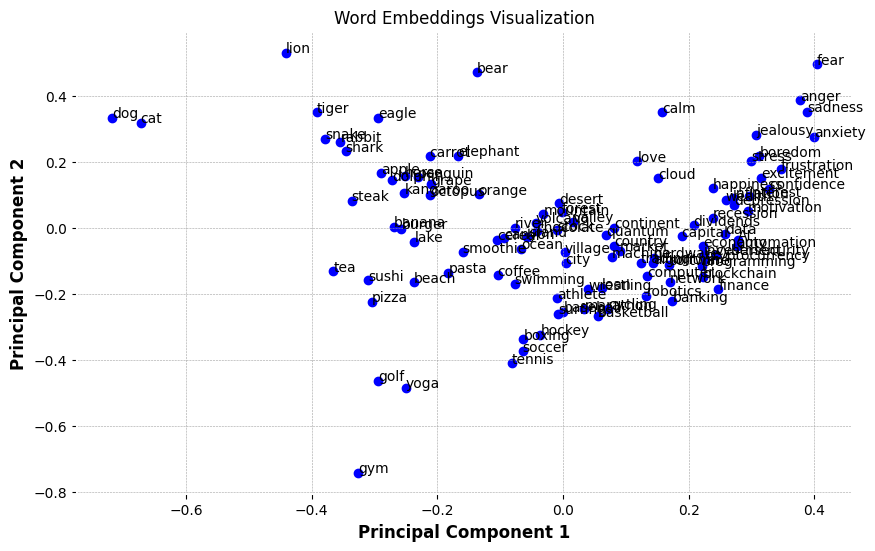

In [32]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# List of words to visualize
words = [
    # Financial Terms
    "stock", "market", "investment", "trading", "finance",
    "economy", "inflation", "cryptocurrency", "banking", "recession",
    "interest", "loan", "capital", "wealth", "dividends",

    # Technological Terms
    "computer", "AI", "algorithm", "programming", "software",
    "hardware", "robotics", "cybersecurity", "network", "data",
    "machine", "automation", "quantum", "cloud", "blockchain",

    # Food and Drink Terms
    "apple", "banana", "grape", "orange", "chocolate",
    "coffee", "tea", "pizza", "burger", "sushi",
    "pasta", "cereal", "smoothie", "carrot", "steak",

    # Sports and Fitness Terms
    "soccer", "basketball", "tennis", "swimming", "marathon",
    "yoga", "gym", "athlete", "baseball", "boxing",
    "hockey", "golf", "cycling", "wrestling", "surfing",

    # Animals Terms
    "dog", "cat", "elephant", "tiger", "lion",
    "dolphin", "eagle", "snake", "horse", "penguin",
    "rabbit", "kangaroo", "shark", "octopus", "bear",

    # Geography and Places Terms
    "mountain", "ocean", "desert", "island", "river",
    "forest", "city", "village", "country", "continent",
    "volcano", "lake", "valley", "beach", "canyon",

    # Emotions and Psychology Terms
    "happiness", "sadness", "anger", "fear", "anxiety",
    "excitement", "boredom", "stress", "motivation", "depression",
    "love", "confidence", "jealousy", "calm", "frustration",
]

# Get word embeddings
embeddings = np.array([fasttext_model[word] for word in words])

# Apply PCA to reduce to 2D
pca = PCA(n_components=2)
reduced_embeddings = pca.fit_transform(embeddings)

# Plot the words in 2D
plt.figure(figsize=(10, 6))
plt.scatter(reduced_embeddings[:, 0], reduced_embeddings[:, 1], marker="o", color="blue")

# Annotate points with words
for i, word in enumerate(words):
    plt.annotate(word, (reduced_embeddings[i, 0], reduced_embeddings[i, 1]))

plt.title("Word Embeddings Visualization")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)
plt.show()


The scatterplot reveals that words tend to cluster based on their semantic categories. For example, "cat" and "dog" appear close together, which makes sense as they are commonly associated as pets. Similarly, other animals like "tiger," "snake," "rabbit," and "shark" are positioned near each other. Sports-related terms, including "tennis," "soccer," "hockey," and "boxing," also form a distinct grouping. Additionally, emotions such as "fear," "anger," "sadness," "anxiety," and "jealousy" are clustered together, reflecting their conceptual similarities.

One interesting observation is the presence of a dense cluster in the middle-right of the plot that does not seem to align with a specific categorical theme. However, a pattern emerges where words gradually increase in length from left to right within this cluster. This suggests that the model may be capturing structural similarities in addition to semantic relationships.

## Part 3: Designing a Novel Dissimilarity Metric

For my dissimilarity metric, I chose to implement Euclidean Distance. The source linked below discusses Euclidean distance alongside various other similarity and dissimilarity measures commonly used for clustering continuous data.

Euclidean distance provides a useful alternative to cosine similarity for capturing novelty and diversity in word embeddings. While cosine similarity focuses on the angle between vectors (directional similarity), Euclidean distance considers the absolute magnitude of differences. This makes it better suited for identifying truly distant words in the embedding space, regardless of direction.

However, Euclidean distance has some drawbacks. For example, two vectors with no shared attributes may have a smaller distance than another pair with overlapping attributes. Additionally, features with larger scales can dominate the distance calculation. To mitigate this, normalization is important. In my implementation, I take the average per-dimension Euclidean distance to ensure fair comparisons across embeddings.

The following code allows the user to input a word and compare it against a list of other words using either cosine similarity or Euclidean distance. The results are visualized in both a bar graph and a heatmap for better interpretation.

Source Link: https://journals.plos.org/plosone/article?id=10.1371/journal.pone.0144059

Source Proper Citation:
A Comparison Study on Similarity and Dissimilarity Measures in Clustering Continuous Data
Shirkhorshidi AS, Aghabozorgi S, Wah TY (2015) A Comparison Study on Similarity and Dissimilarity Measures in Clustering Continuous Data. PLOS ONE 10(12): e0144059. https://doi.org/10.1371/journal.pone.0144059

In [33]:
import seaborn as sns

def plot_ranking(word, similarity_scores, metric="cosine"):

  # Sort words based on similarity scores (descending for similarity)
  similarity_scores.sort(key=lambda x: x[1], reverse=True)

  # Extract words and scores for plotting
  words = [x[0] for x in similarity_scores]
  scores = [x[1] for x in similarity_scores]

  # Plotting
  plt.figure(figsize=(10, 6))
  sns.barplot(x=scores, y=words)
  plt.title(f"Ranking of Words Based on {metric.capitalize()} Similarity/Dissimilarity to '{word}'")
  plt.xlabel("Similarity/Dissimilarity Score")
  plt.ylabel("Words")
  plt.show()

def create_heatmap(word, similarity_scores, metric="cosine"):
  # Extract words and scores for plotting
  words = [x[0] for x in similarity_scores]
  scores = [x[1] for x in similarity_scores]

  # Convert to a 2D array for heatmap
  scores_matrix = np.array(scores).reshape(1, -1)

  # Plot the heatmap
  plt.figure(figsize=(10, 2))
  ax = sns.heatmap(scores_matrix, annot=True, cmap="coolwarm", xticklabels=words, yticklabels=[word1])
  plt.title(f"{metric.capitalize()} Similarity/Dissimilarity of Words to '{word}'")
  plt.xlabel("Words")
  plt.ylabel("Reference Word")
  plt.show()

def visualize_dissimilarity_metrics(word, comparison_list, model, metric="cosine"):
  # Create an array for similarity scores between all combinations of words
  results = []
  for w in comparison_list:
    score = None
    if metric == "cosine":
      cosine_sim = cosine_similarities([(word, w)])
      score = cosine_sim[(word, w)]                     # Higher is better
    elif metric == "euclidean":
      embedding1 = get_embedding(word)
      embedding2 = get_embedding(w)
      score = np.mean(np.abs(embedding1 - embedding2))  # Mean per-dimension euclidian distance
    else:
      print("Invalid Metric")
      return
    results.append((w, score))

  # Plot rankings
  plot_ranking(word, results, metric)

  # Create a heatmap
  create_heatmap(word, results, metric)

To demonstrate my functions in action, I test comparing cat to a variety of other animals, and inanimate objects below:

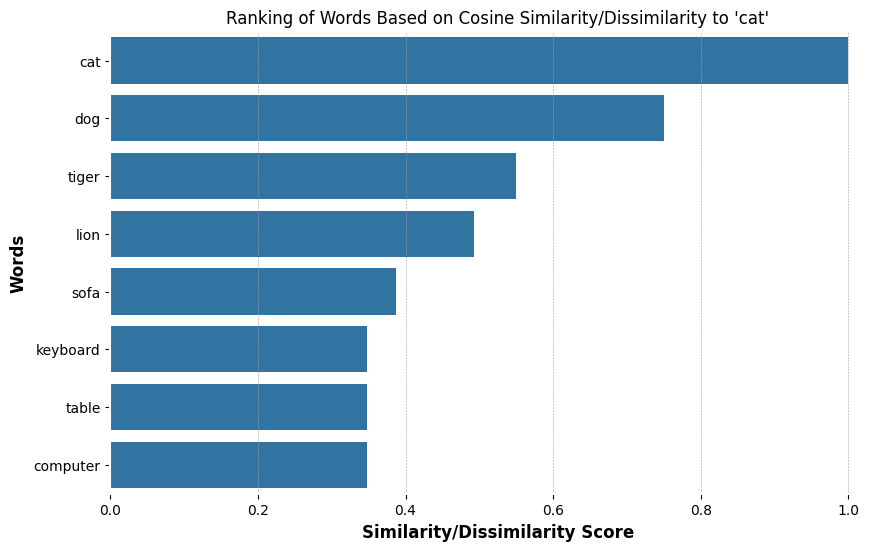

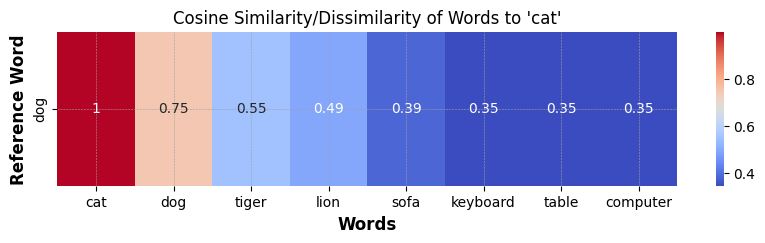

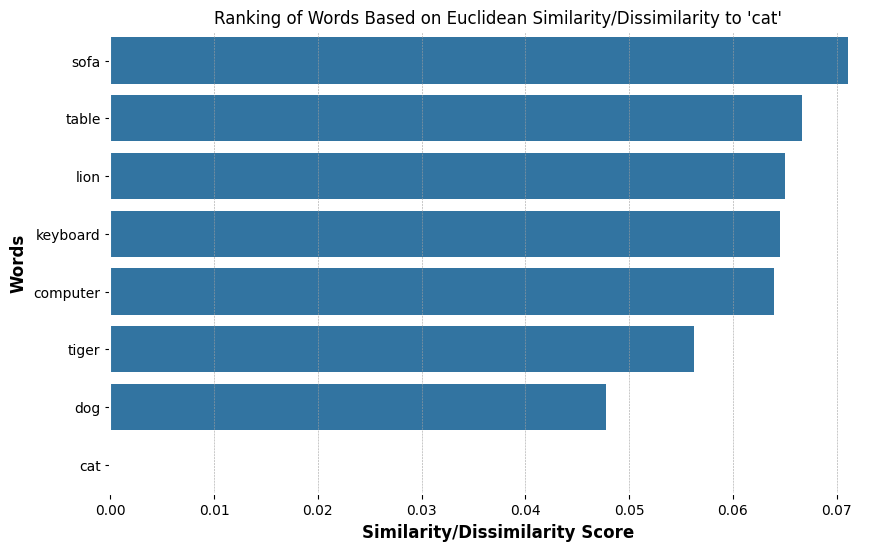

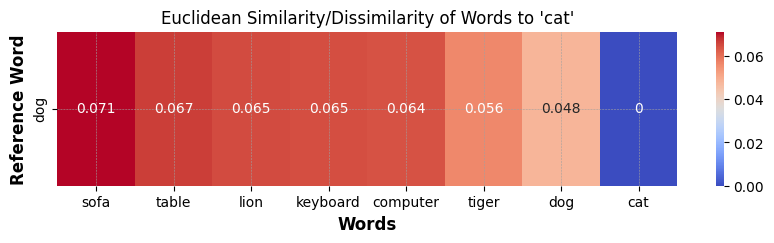

In [34]:
# Testing my functions
word = "cat"
comparison_list = ["dog", "cat", "lion", "tiger", "table", "sofa", "computer", "keyboard"]
visualize_dissimilarity_metrics(word, comparison_list, fasttext_model, metric="cosine")
visualize_dissimilarity_metrics(word, comparison_list, fasttext_model, metric="euclidean")

From the above graphs, we obtain the following rankings based on cosine similarity and Euclidean dissimilarity:

* Cosine Similarity (most similar first): cat, dog, tiger, lion, sofa, keyboard, table, computer
* Euclidean Dissimilarity (most dissimilar first): sofa, table, lion, keyboard, computer, tiger, dog, cat

These results highlight key differences between the two metrics. Cosine similarity effectively groups words by semantic meaning, placing "cat" at the top (since it is the exact input), followed by closely related animals like "dog," "tiger," and "lion," and finally transitioning to inanimate objects.

Euclidean dissimilarity also follows a logical pattern, with "sofa" having the highest value, meaning it is the most distant word in the vector space. This aligns with expectations, as "sofa" shares little semantic or structural similarity with "cat." The ranking follows a similar trend to cosine similarity, with inanimate objects generally exhibiting greater distances and animals appearing closer. However, "lion" is an exception, ranking further away than "keyboard" and "computer." This suggests that, in the embedding space, the word "lion" may have structural differences that increase its Euclidean distance despite being semantically closer to "cat."

These observations demonstrate that while cosine similarity captures semantic relatedness, Euclidean distance highlights absolute differences in embedding space, making it useful for identifying truly novel or diverse words.


# Statement About Use of Generative AI

Throughout this project, I leveraged generative AI models to help refine the structure and grammar of my writing. I also used them to format some of my code for better readability and consulted them for guidance on which NumPy, Pandas, and other functions to use before researching and implementing them myself. All content presented is my own, and any external sources referenced for this assignment are properly cited or linked where appropriate. I wasn't sure of the exact citation format for AI usage, so I felt this paragraph would suffice.

I thoroughly enjoyed completing this assignment and deepening my understanding of so many new concepts!